In [1]:
# Import libraries'

import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading the Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data cleanup 
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

In [2]:
df_us = df[df['job_country'] == 'United States']

In [7]:
df_us['job_posted_month'] = df['job_posted_date'].dt.strftime('%B') #%m take the month from the date and return it as a string with 2 digits (01,02,...,12), %B take the month from the date and return it as a string with the full name of the month (January, February,..., December)

In [9]:
df_us_pivot = df_us.pivot_table(index='job_posted_month',columns='job_title_short',aggfunc='size') # size means count the number of rows in each group

In [10]:
df_us_pivot.reset_index(inplace=True) #inplace measns that the changes will be made to the original dataframe, not a copy of it

In [13]:
df_us_pivot['month_no'] = pd.to_datetime(df_us_pivot['job_posted_month'],format='%B').dt.month # convert the month name to month number

df_us_pivot.sort_values(by='month_no', inplace=True) # sort the dataframe by month number

In [14]:
df_us_pivot.set_index('job_posted_month', inplace=True) # set the index to the month name

In [15]:
df_us_pivot.drop(columns='month_no',inplace=True) # drop the month number column

In [16]:
df_us_pivot

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_posted_month,,,,,,,,,,
January,527,36,8494,2655,6915,60,1544,773,1552,114
February,447,24,6124,3060,4956,56,1258,878,1127,90
March,438,19,6218,3183,4779,59,1114,829,1150,115
April,565,40,6049,2801,4867,51,1025,781,991,112
May,279,20,4993,2976,4377,49,839,746,914,90
June,446,32,5683,2893,4645,48,1009,812,1033,93
July,581,39,5201,2570,4876,65,883,747,1095,153
August,903,39,6634,3269,6318,68,1186,903,1515,194
September,897,50,4639,3224,4568,113,805,775,1014,228


<Axes: title={'center': 'Job Demand in the United States by Month'}, xlabel='Month', ylabel='Number of Job Postings'>

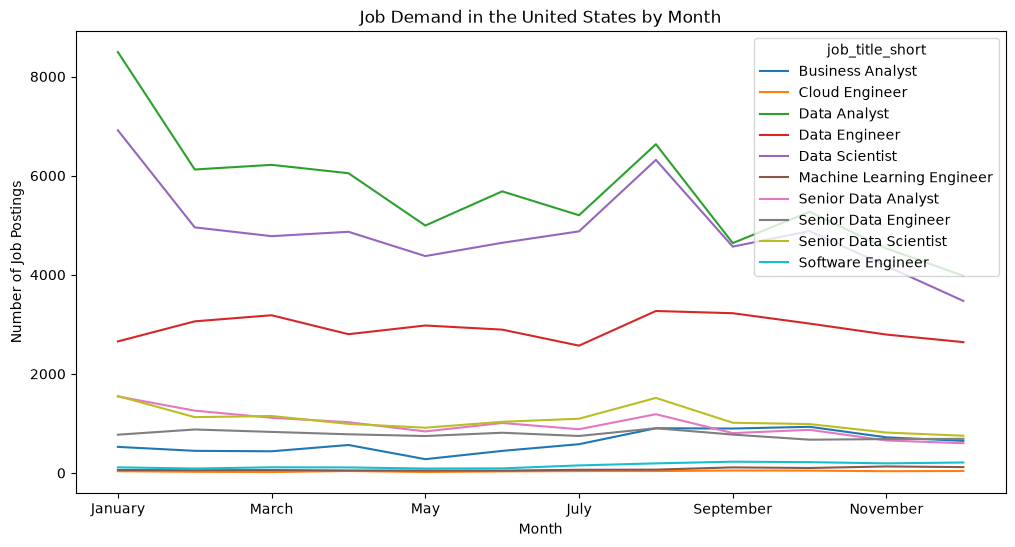

In [ ]:
df_us_pivot.plot(kind='line',figsize=(12,6),title='Job Demand in the United States by Month',xlabel='Month',ylabel='Number of Job Postings')
#figsize is the size of the figure in inches, title is the title of the plot, xlabel is the label of the x-axis, ylabel is the label of the y-axis

In [ ]:
top_3 = df_us['job_title_short'].value_counts().head(3).index.tolist()
# get the top 3 job titles
# .index.tolist() is used to get the index of the series as a list

<Axes: title={'center': 'Top 3 Job Demand in the United States by Month'}, xlabel='Month', ylabel='Number of Job Postings'>

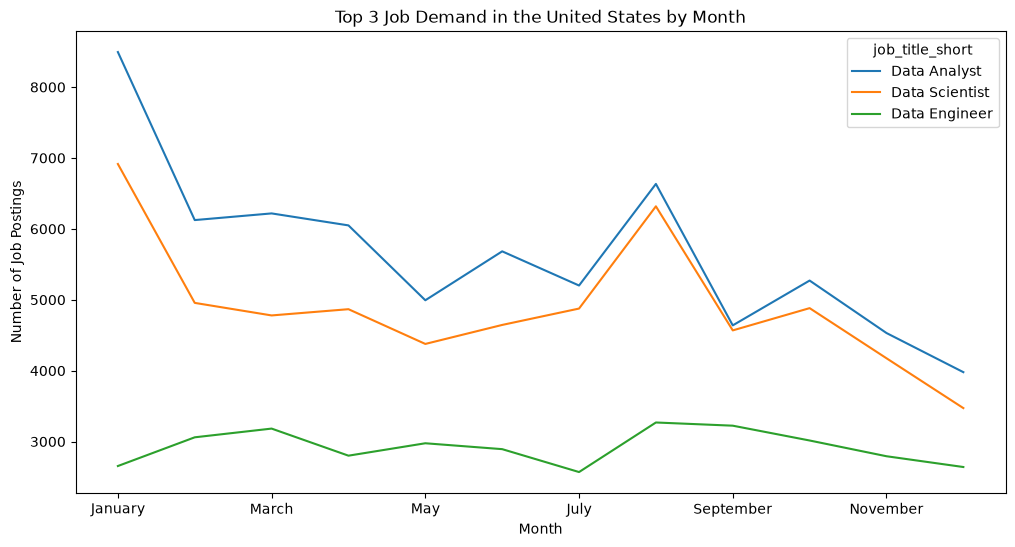

In [28]:
df_us_pivot[top_3].plot(kind='line',ylabel ='Number of Job Postings',xlabel='Month',title='Top 3 Job Demand in the United States by Month',figsize=(12,6))